In [1]:
import samna
import samna.dynapse1 as dyn1
import time
import sys
import numpy as np
import matplotlib.pyplot as plt
sys.path.append('../.')

import dynapse1utils as ut
from netgen import NetworkGenerator, Neuron

import pynwb
import h5py
from pynwb import NWBHDF5IO
import os
import pandas as pd

In [5]:
print(sys.version)

3.8.20 (default, Oct  3 2024, 15:24:27) 
[GCC 11.2.0]


In [2]:
model,_ = ut.open_dynapse1(gui=False, select_device= True)

[0]:  Bus 1 Device 64 Dynapse1DevKit serial_number 00000026
[1]:  Bus 1 Device 51 Dynapse1DevKit serial_number 00000092
[2]:  Bus 1 Device 32 Dynapse1DevKit serial_number 00000000
[3]:  Bus 1 Device 65 Dynapse1DevKit serial_number 00000033
[4]:  Bus 1 Device 66 Dynapse1DevKit serial_number 00000001
[5]:  Bus 1 Device 67 Dynapse1DevKit serial_number 00000007
[6]:  Bus 1 Device 63 Dynapse1DevKit serial_number 00000020


Select the device you want to open by index:  0


Selected device: 00000026
Sender port: tcp://0.0.0.0:53875
Receiver port: tcp://0.0.0.0:34197
Opened device name: Dynapse1DevKit
SamnaNode ID: 1
PythonNode ID: 2


In [6]:
# get Dynapse1 api from the model
api = model.get_dynapse1_api()
chip_id = 0
neuron_id = 10
api.monitor_neuron(chip_id, neuron_id)

In [7]:
net_gen = NetworkGenerator()
net_gen.clear_network() # Clear any existing network structure

neurons_E= []
NE_pos = 16
E_ids = [(0,0,i) for i in range(1,NE_pos+1)]
for nid in E_ids:
    neurons_E.append(Neuron(nid[0],nid[1],nid[2]))
print(neurons_E)

NI= 8
I_ids = [(0,0,i) for i in range(NE_pos+1, (NE_pos+1)+NI+1)]
neurons_I = []
for nid in I_ids:
    neurons_I.append(Neuron(nid[0],nid[1],nid[2]))
print(neurons_I)

[C0c0n1, C0c0n2, C0c0n3, C0c0n4, C0c0n5, C0c0n6, C0c0n7, C0c0n8, C0c0n9, C0c0n10, C0c0n11, C0c0n12, C0c0n13, C0c0n14, C0c0n15, C0c0n16]
[C0c0n17, C0c0n18, C0c0n19, C0c0n20, C0c0n21, C0c0n22, C0c0n23, C0c0n24, C0c0n25]


In [ ]:
D_stim = 3 # stimulus duration (s)
D_post_stim = 3 # post stimulus duration (s)
D = D_stim + D_post_stim

In [9]:
monitored_neurons = E_ids + I_ids
graph, filter_node, sink_node = ut.create_neuron_select_graph(model, monitored_neurons)
graph.start()
# clear the buffer
sink_node.get_events()

api.reset_timestamp()
"""
time.sleep(D_stim)

time.sleep(D_post_stim)
"""
graph.stop()
events = sink_node.get_events()

# process the events
print(len(events),"events.")

0 events.


In [10]:
NN = 256 # neurons in 1 core
spike_id_pos = []
spike_t_pos  = []
for evt in events:
    #print(evt.core_id)
    spike_id_pos.append(evt.core_id*NN + evt.neuron_id)
    spike_t_pos.append(evt.timestamp*1e-6)
spike_id_pos = np.array(spike_id_pos)
spike_t_pos  = np.array(spike_t_pos) 

In [22]:
NE_pre = 61
PRESYNAPTIC=True
with NWBHDF5IO("sub-489_ses-20220708.nwb", "r") as io: #turns left
    nwb = io.read()
    units= nwb.units    
    spikes={}
    l4_ol_l = range(NE_pre) #move min(l4_ol_l) to 25 or we have a clash
    for i in l4_ol_l:
        spikes[f"neuron_{i}"]=  (i, units.get_unit_spike_times(i))
    spike_id_prl = []
    spike_t_prl =[]
    #print(spikes.items())
    #print(spikes["neuron_12"])
    for neuron_id ,(int_id, times) in spikes.items():
        spike_id_prl.extend(len(times)*[int_id])
        spike_t_prl.extend(times)
    spike_id_prl = np.array(spike_id_prl)
    spike_t_prl = np.array(spike_t_prl)
    sorted_idx = np.argsort(spike_t_prl)
    spike_id_prl = spike_id_prl[sorted_idx]
    spike_t_prl = spike_t_prl[sorted_idx]
    
    #print(spikes["neuron_12"])
    print(spike_t_prl)
    print(spike_id_prl)
    pd.DataFrame(spike_t_prl).to_csv("turn_left_spike_times.csv", index= False)
    pd.DataFrame(spike_id_prl).to_csv("turn_left_spike_ids.csv", index= False)
"""
with NWBHDF5IO("sub-503_ses-20220902.nwb", "r") as io: #turns left
    nwb = io.read()
    units= nwb.units    
    spikes={}
    l4_ol_r = range(12,25)
    for i in l4_ol_r:
        spikes[f"neuron_{i}"]=  (i, units.get_unit_spike_times(i))
    spike_id_prr = []
    spike_t_prr =[]
    #print(spikes.items())
    #print(spikes["neuron_12"])
    for neuron_id ,(int_id, times) in spikes.items():
        spike_id_prr.extend(len(times)*[int_id])
        spike_t_prr.extend(times)
    spike_id_prr = np.array(spike_id_prr)
    spike_t_prr = np.array(spike_t_prr)
    sorted_idx = np.argsort(spike_t_prr)
    spike_id_prr = spike_id_prr[sorted_idx]
    spike_t_prr = spike_t_prr[sorted_idx]
    
    #print(spikes["neuron_12"])
    print(spike_t_prr)
    print(spike_id_prr)
    pd.DataFrame(spike_t_prr).to_csv("turn_right_spike_times.csv", index= False)
    pd.DataFrame(spike_id_prr).to_csv("turn_right_spikes_ids.csv", index= False)
spike_t_pre = np.concatenate([spike_t_prl, spike_t_prr])
spike_id_pre = np.concatenate([spike_id_prl, spike_id_prr])
sorted_idx_glb = np.argsort(spike_t_pre)
spike_t_pre = spike_t_pre[sorted_idx_glb]
spike_id_pre = spike_id_pre[sorted_idx_glb]
"""
spike_t_pre = spike_t_prl
spike_id_pre = spike_id_prl
pd.DataFrame(spike_t_pre).to_csv("all_spike_times.csv", index= False)
pd.DataFrame(spike_id_pre).to_csv("all_spikes_ids.csv", index= False)
print(max(spike_t_pre))


[6.60000000e-03 1.67666667e-02 2.64000000e-02 ... 6.25530580e+03
 6.25530623e+03 6.25530660e+03]
[50 51 38 ... 42 50 49]
6255.3066


ValueError: x and y must be the same size

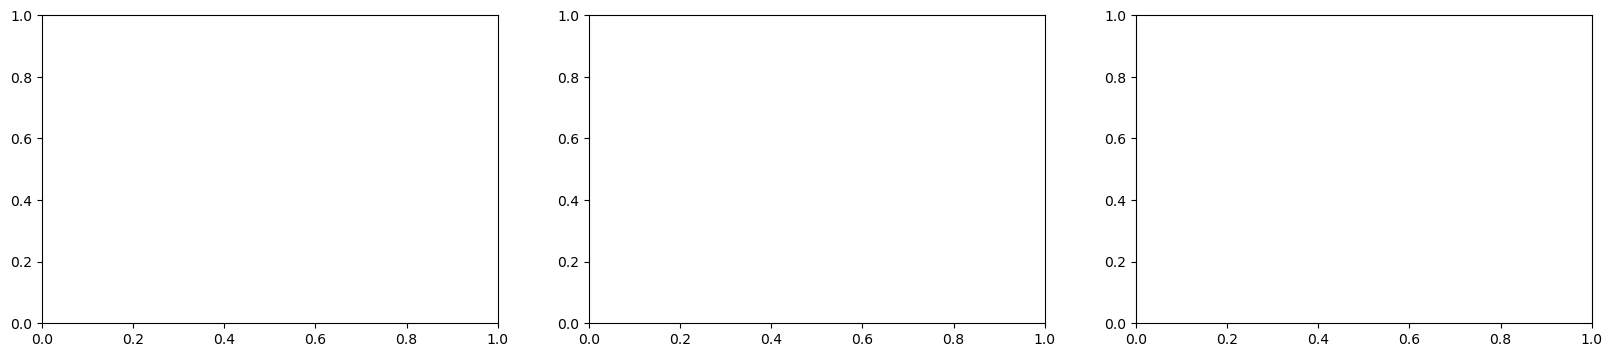

In [23]:
# E mean firing rate
PRESYNAPTIC=True
if(PRESYNAPTIC):
    spike_t = spike_t_pre
    spike_id = spike_id_pre
    NE=NE_pre
    NI=NE
    labelx = ['R', 'L']
    D_start= np.array([6.3, 15.7, 25.95, 68.8, 76.57])
    D_end = np.array([8.3, 17.7, 27.95, 70.8, 78.57])
    D_min= 2*D_start - D_end
    D_max=2*D_end -D_start
    D_stim = [D_min, D_start, D_end, D_max]
    D=D_max - D_min
    fs=200
else:
    spike_t = spike_t_pos
    spike_id = spike_id_pos
    NE = NE_pos
    labelx = ['E', 'I']
    spike_range = len(events)
    fs = 200
    D_stim = 3 # stimulus duration (s)
    D_post_stim = 3 # post stimulus duration (s)
    D = D_stim + D_post_stim
    


binPOP = np.zeros((2,int(D_max[-1]*fs)))

if(not PRESYNAPTIC):
    for i in range(spike_range):
        if(spike_t[i]<D):
            group_idx = min(spike_id[i] // NE, 1) 
            binPOP[group_idx,int(spike_t[i]*fs)]=1

    sigma = 0.01
    x = np.arange(int(-0.2*fs),int(0.2*fs))/fs
    gauss = np.exp(-x**2/sigma)

    binPOP[0] = np.convolve(binPOP[0],gauss,'same')
    binPOP[1] = np.convolve(binPOP[1],gauss,'same')
    f, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20,4))
    ax2.scatter(binPOP[0,:int(D_stim*fs)]/NE,binPOP[1,:int(D_stim*fs)]/NI,c='k',s=5,label='During stimulus')
    ax2.scatter(binPOP[0,int(D_stim*fs):]/NE,binPOP[1,int(D_stim*fs):]/NI,c='red',s=5,label='Post stimulus')
    ax2.set_ylabel(f"firing rate {labelx[0]} POP")
    ax2.set_xlabel(f'firing rate {labelx[1]} POP')
    ax2.legend()

    ax3.plot(np.arange(int(D_stim*fs))/fs,binPOP[0,:int(D_stim*fs)]/NE+binPOP[1,:int(D_stim*fs)]/NI,c='k',label='E-I During stim.')
    ax3.plot(np.arange(int(D_post_stim*fs))/fs+int(D_stim*fs)/fs,binPOP[0,int(D_stim*fs):]/NE-binPOP[1,int(D_stim*fs):]/NI,c='red',label='E-I Post stim.')
    ax1.scatter(spike_t[spike_id<(NE)],spike_id[spike_id<(NE)],marker='|',label=labelx[0])
    ax1.scatter(spike_t[spike_id>(NE)],spike_id[spike_id>(NE)],marker='|',label=labelx[1])
    ax1.set_xlabel('time (s)')
    ax1.set_ylabel('neuron id')
    ax1.legend()
    ax1.set_xlim(0,D)

else:
    f, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20,4))
    


for i in range(len(D_max)):
    spike_max = np.sum(spike_t<D_max[i])
    spike_min = np.sum(spike_t<D_min[i])
    for j in range(spike_min, spike_max):
        if(D_min[i]< spike_t[j]<D_max[i]):
            #print(j, spike_id[j])
            group_idx = min(spike_id[j] // NE, 1) 
            binPOP[group_idx,int(spike_t[j]*fs)]=1
    sigma = 0.01
    x = np.arange(int(-0.2*fs),int(0.2*fs))/fs
    gauss = np.exp(-x**2/sigma)

    binPOP[0] = np.convolve(binPOP[0],gauss,'same')
    binPOP[1] = np.convolve(binPOP[1],gauss,'same')
    if(len(binPOP[0,int(D_stim[0][i]*fs):int(D_stim[1][i]*fs)]) > len(binPOP[0,int(D_stim[1][i]*fs):int(D_stim[2][i]*fs)]):
        binPOP[0,int(D_stim[1][i]*fs):int(D_stim[2][i]*fs)]= np.resize(0,len(binPOP[0,int(D_stim[0][i]*fs):int(D_stim[1][i]*fs)]))
    else:
        binPOP[0,int(D_stim[0][i]*fs):int(D_stim[1][i]*fs)] = np.resize(0, len(binPOP[0,int(D_stim[1][i]*fs):int(D_stim[2][i]*fs)]))
    if(len(binPOP[0,int(D_stim[2][i]*fs):int(D_stim[3][i]*fs)])> len(binPOP[0,int(D_stim[1][i]*fs):int(D_stim[2][i]*fs)])):
        binPOP[0,int(D_stim[1][i]*fs):int(D_stim[2][i]*fs)] = np.resize(0, len(binPOP[0,int(D_stim[2][i]*fs):int(D_stim[3][i]*fs)]))
    else:
    
    ax2.scatter(binPOP[0,int(D_stim[0][i]*fs):int(D_stim[1][i]*fs)],binPOP[0,int(D_stim[1][i]*fs):int(D_stim[2][i]*fs)],c='k',s=5,label='Pre')
    ax2.scatter(binPOP[0,int(D_stim[2][i]*fs):int(D_stim[3][i]*fs)],binPOP[0,int(D_stim[1][i]*fs):int(D_stim[2][i]*fs)],c='red',s=5,label='Post')
    #ax2.set_ylabel(f"firing rate {labelx[0]} POP")
    #ax2.set_xlabel(f'firing rate {labelx[1]} POP')
    ax2.legend(loc='upper right', ncol=2)
    time = np.arange(binPOP.shape[0]) / fs
    #ax3.plot(time, binPOP[0]/NE,label= labelx[0])
    ax3.plot(time,-binPOP[0]/NI,label= labelx[1])
    ax3.plot([D_min[i],D_max[i]],[0,0],'gray')
    ax3.set_ylabel('signed firing rate')
    ax3.set_xlabel('time (s)')
    ax3.legend(loc='upper right', ncol=2)
    ax3.set_ylim(-2,2)
    ax3.set_xlim(D_min[i], D_max[i])
    #ax1.scatter(spike_t[spike_id<(NE)],spike_id[spike_id<(NE)],marker='|',label=labelx[0])
    ax1.scatter(spike_t[spike_id<(NE)],spike_id[spike_id<(NE)],marker='|',label=labelx[1])
    ax1.set_xlabel('time (s)')
    ax1.set_ylabel('neuron id')
    ax1.legend()
    ax1.set_xlim(D_min[i],D_max[i])
    plt.tight_layout()
    plt.savefig(f'Pre-During-Pos{D_start[i]}.png')
    plt.show(label=f'OL_L_1: times{D_start[i]} till {D_end[i]}')